# GA + Laberinto

Esta celda genera un **laberinto aleatorio** y entrena, con un **Algoritmo Genético (GA)**, una secuencia de movimientos para que un agente salga desde `(1,1)` hasta la meta `(H-2, W-2)`. La **animación inline** muestra el recorrido del mejor individuo (con submuestreo para aligerar).

## Parámetros clave
- **Tamaño del laberinto**: `n` ⇒ tamaño real `(2n+1)×(2n+1)`.
- **Tiempo de prueba / longitud del genoma**: `GAConf.len_genoma` (más grande = más pasos permitidos).
- **GA**: `tam_pobl`, `generaciones`, `p_mut`, `elitismo`, `torneo_k`, `semilla`.
- **Animación**: `step` (p.ej., 8) y `fps` (p.ej., 18).

> Tip: Aumenta `len_genoma` si el agente suele quedarse corto antes de alcanzar la meta.


GIF guardado en: C:\Users\rjcbm\Documents\ANAANACONDA\AG\ga_laberinto_inline.gif


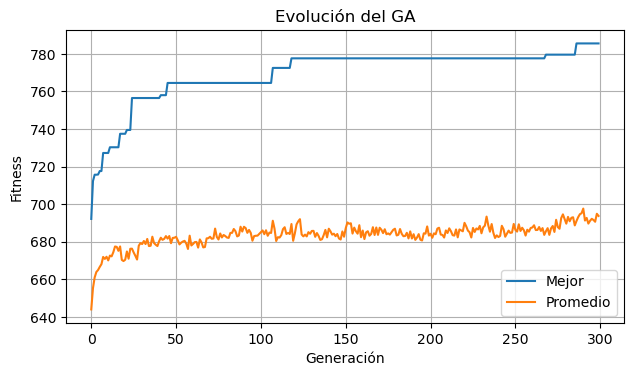

In [ ]:
# -*- coding: utf-8 -*-
# Celda 1: utilidades, GA y animación inline para Jupyter

from __future__ import annotations
import os
import random
from dataclasses import dataclass
from typing import List, Tuple
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from collections import deque
from IPython.display import HTML, display

# ====================== Generación del laberinto ======================
def generar_laberinto(n: int, semilla: int = 0) -> np.ndarray:
    """
    Genera un laberinto binario de tamaño (2n+1)x(2n+1).
    1 = muro, 0 = camino. Método: DFS (backtracking) sobre nodos (n x n).
    """
    rnd = random.Random(semilla)
    H, W = 2 * n + 1, 2 * n + 1
    maze = np.ones((H, W), dtype=np.uint8)
    visited = np.zeros((n, n), dtype=bool)
    dirs = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # N, E, S, O

    def carve(r: int, c: int):
        visited[r, c] = True
        maze[2 * r + 1, 2 * c + 1] = 0
        orden = dirs[:]
        rnd.shuffle(orden)
        for dr, dc in orden:
            nr, nc = r + dr, c + dc
            if 0 <= nr < n and 0 <= nc < n and not visited[nr, nc]:
                # abrir muro entre celdas
                maze[2 * r + 1 + dr, 2 * c + 1 + dc] = 0
                carve(nr, nc)

    carve(0, 0)
    return maze

# ====================== Distancia BFS a la meta ======================
def distancia_bfs(maze: np.ndarray, goal: Tuple[int, int]) -> np.ndarray:
    H, W = maze.shape
    dist = np.full((H, W), np.inf, dtype=float)
    q = deque()
    gy, gx = goal
    if maze[gy, gx] == 1:
        raise ValueError("La meta está en un muro.")
    dist[gy, gx] = 0.0
    q.append((gy, gx))
    while q:
        y, x = q.popleft()
        for dy, dx in [(-1,0),(1,0),(0,-1),(0,1)]:
            ny, nx = y + dy, x + dx
            if 0 <= ny < H and 0 <= nx < W and maze[ny, nx] == 0 and dist[ny, nx] == np.inf:
                dist[ny, nx] = dist[y, x] + 1.0
                q.append((ny, nx))
    return dist

# ====================== Simulación de movimientos ======================
Move = int  # 0: up, 1: right, 2: down, 3: left

def aplicar_movimientos(maze: np.ndarray, start: Tuple[int,int], moves: List[Move]) -> Tuple[List[Tuple[int,int]], int, bool, int, int]:
    """
    Devuelve:
      trayectoria (lista de posiciones), colisiones,
      reached (si alcanzó la meta), t_reach (paso), pasos_efectivos.
    """
    H, W = maze.shape
    y, x = start
    trayectoria = [(y, x)]
    colisiones = 0
    pasos_efectivos = 0

    goal = (H - 2, W - 2)
    reached = False
    t_reach = len(moves)

    for t, m in enumerate(moves):
        dy, dx = (0,0)
        if m == 0: dy = -1
        elif m == 1: dx = 1
        elif m == 2: dy = 1
        elif m == 3: dx = -1
        ny, nx = y + dy, x + dx
        if 0 <= ny < H and 0 <= nx < W and maze[ny, nx] == 0:
            y, x = ny, nx
            pasos_efectivos += 1
        else:
            colisiones += 1
        trayectoria.append((y, x))
        if (y, x) == goal and not reached:
            reached = True
            t_reach = t + 1

    return trayectoria, colisiones, reached, t_reach, pasos_efectivos

# ====================== Fitness ======================
def fitness_trayectoria(maze: np.ndarray, traj: List[Tuple[int,int]], colisiones: int, reached: bool, t_reach: int, dist_map: np.ndarray) -> float:
    y, x = traj[-1]
    d = dist_map[y, x]
    if np.isinf(d):
        d = 1e6

    if reached:
        base = 10000.0 + (len(traj) - t_reach)  # llega y antes es mejor
    else:
        base = 1000.0 - d                       # cuanto más cerca, mejor

    uniq = len(set(traj))
    fit = base - 0.5 * colisiones + 0.01 * uniq
    return float(fit)

# ====================== GA ======================
@dataclass
class GAConf:
    tam_pobl: int = 140
    generaciones: int = 140
    len_genoma: int = 800   # “tiempo de prueba” (pasos máximos)
    p_mut: float = 0.06
    elitismo: int = 6
    torneo_k: int = 4
    semilla: int = 2025

def seleccion_torneo(pobl, aptitudes, k, rnd: random.Random):
    idxs = rnd.sample(range(len(pobl)), k)
    mejor = max(idxs, key=lambda i: aptitudes[i])
    return pobl[mejor]

def cruzar_2pt(a: np.ndarray, b: np.ndarray, rnd: random.Random):
    n = len(a)
    i, j = sorted(rnd.sample(range(n), 2))
    h1 = a.copy(); h2 = b.copy()
    h1[i:j], h2[i:j] = b[i:j], a[i:j]
    return h1, h2

def mutar(g: np.ndarray, p_mut: float, rnd: random.Random):
    mask = np.random.rand(len(g)) < p_mut
    if mask.any():
        g[mask] = np.random.randint(0, 4, size=mask.sum(), dtype=np.int8)

def ejecutar_ga(maze: np.ndarray, start=(1,1), conf=GAConf()):
    rnd = random.Random(conf.semilla)
    H, W = maze.shape
    goal = (H-2, W-2)
    dist_map = distancia_bfs(maze, goal)

    # población inicial
    pobl = [np.random.randint(0,4,size=conf.len_genoma,dtype=np.int8) for _ in range(conf.tam_pobl)]

    mejor, mejor_fit, mejor_traj = None, -1e18, None
    historial = []

    for gen in range(conf.generaciones):
        aptitudes = []
        trayectorias = []
        for individuo in pobl:
            traj, col, reached, t_reach, pasos = aplicar_movimientos(maze, start, individuo.tolist())
            trayectorias.append(traj)
            fit = fitness_trayectoria(maze, traj, col, reached, t_reach, dist_map)
            aptitudes.append(fit)

        # actualizar mejor
        idx_mejor_gen = int(np.argmax(aptitudes))
        if aptitudes[idx_mejor_gen] > mejor_fit:
            mejor_fit = float(aptitudes[idx_mejor_gen])
            mejor = pobl[idx_mejor_gen].copy()
            mejor_traj = trayectorias[idx_mejor_gen]

        historial.append((gen, mejor_fit, float(np.mean(aptitudes))))

        # nueva población (elitismo + cruce/mutación)
        orden = np.argsort(aptitudes)[::-1]
        nueva = [pobl[i].copy() for i in orden[:conf.elitismo]]
        while len(nueva) < conf.tam_pobl:
            p1 = seleccion_torneo(pobl, aptitudes, conf.torneo_k, rnd)
            p2 = seleccion_torneo(pobl, aptitudes, conf.torneo_k, rnd)
            h1, h2 = cruzar_2pt(p1, p2, rnd)
            mutar(h1, conf.p_mut, rnd)
            mutar(h2, conf.p_mut, rnd)
            nueva.append(h1)
            if len(nueva) < conf.tam_pobl:
                nueva.append(h2)
        pobl = nueva

    return mejor, mejor_traj, np.array(historial)

# ====================== Animación inline para Jupyter ======================
def animar_trayectoria_inline(maze: np.ndarray, trayectoria: List[Tuple[int,int]], step: int = 6, fps: int = 20, titulo="Agente saliendo del laberinto"):
    """
    Muestra la animación *inline* (JS/HTML) en Jupyter.
    step>1 submuestrea la trayectoria para hacer más liviana la animación.
    """
    if step > 1:
        trayectoria = trayectoria[::step] + [trayectoria[-1]]

    fig, ax = plt.subplots(figsize=(5,5))
    ax.imshow(maze, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(titulo)

    (punto,) = ax.plot([], [], marker="o", markersize=6, linestyle="")
    linea, = ax.plot([], [], linewidth=2)

    sy, sx = 1, 1
    gy, gx = maze.shape[0]-2, maze.shape[1]-2
    ax.plot([sx],[sy], marker="s")
    ax.plot([gx],[gy], marker="X")

    xs, ys = [], []
    def init():
        punto.set_data([], []); linea.set_data([], [])
        return punto, linea

    def update(frame):
        y, x = trayectoria[frame]
        xs.append(x); ys.append(y)
        punto.set_data([x], [y])
        linea.set_data(xs, ys)
        return punto, linea

    ani = animation.FuncAnimation(fig, update, init_func=init, frames=len(trayectoria), interval=1000/fps, blit=True)
    html = ani.to_jshtml(fps=fps, default_mode="loop")
    plt.close(fig)
    display(HTML(html))
    return ani  # por si también quieres guardarlo como GIF luego
    # Celda 2: ejecutar GA y visualizar inline

# Parámetros principales
n = 12            # laberinto (2n+1)x(2n+1)
semilla_lab = 7
start = (1,1)

# “Tiempo de prueba”: sube len_genoma si quieres más pasos por episodio
conf = GAConf(
    tam_pobl=200,
    generaciones=300,
    len_genoma=1000,   # más alto => más pasos permitidos
    p_mut=0.06,
    elitismo=6,
    torneo_k=4,
    semilla=2025
)

# Entrenar
maze = generar_laberinto(n, semilla=semilla_lab)
mejor, mejor_tray, hist = ejecutar_ga(maze, start=start, conf=conf)

# Mostrar animación inline (submuestreo step para que no sea pesada)
ani = animar_trayectoria_inline(maze, mejor_tray, step=8, fps=18)

# (Opcional) guardar un GIF liviano
gif_path = "ga_laberinto_inline.gif"
ani.save(gif_path, writer=animation.PillowWriter(fps=18), dpi=110)
print("GIF guardado en:", os.path.abspath(gif_path))

# Curva de evolución (figura aparte)
fig, ax = plt.subplots(figsize=(7.2,3.8))
ax.plot(hist[:,0], hist[:,1], label="Mejor")
ax.plot(hist[:,0], hist[:,2], label="Promedio")
ax.set_xlabel("Generación")
ax.set_ylabel("Fitness")
ax.set_title("Evolución del GA")
ax.legend()
ax.grid(True)
plt.show()